# Task 1 : Set up colab gpu runtime environment

In [1]:
!pip install segmentation-models-pytorch
!pip install -U git+https://github.com/albumentations-team/albumentations
!pip install --upgrade opencv-contrib-python

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: /usr/bin/python3 -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable
  Cloning https://github.com/albumentations-team/albumentations to /tmp/pip-req-build-br9feqwy
  Running command git clone --filter=blob:none --quiet https://github.com/albumentations-team/albumentations /tmp/pip-req-build-br9feqwy
  Resolved https://github.com/albumentations-team/albumentations to commit 649fa0d8f3bbbaa4406359fdc244cedbae58f7d8
  Installing build dependenciesdone
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached scipy-1.15.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached scipy-1.15.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (37.6 MB)
  Created wheel for albumentations: 

# About Dataset

### Dataset




# Some Common Imports

In [2]:
import torch
import cv2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tqdm import tqdm

import helper

/home/rukaia/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


# Task : 2 Setup Configurations

In [3]:
CSV_FILE = 'dataset.csv'
DATA_DIR = 'data/MRI_kaggle/kaggle_3m'
DEVICE = 'cuda'
EPOCH = 25
LR = 1e-4
BATCH_SIZE = 8
IMG_SIZE = 512

ENCODER = 'timm-efficientnet-b0'
WEIGHTS = 'imagenet'

In [4]:
CSV_FILE

'dataset.csv'

In [5]:
import torch

if torch.cuda.is_available():
    print("CUDA is available. You are using a GPU.")
else:
    print("CUDA is not available. Using CPU.")


CUDA is available. You are using a GPU.


In [6]:
df = pd.read_csv(CSV_FILE) 

print(df.head(20))
#ssconvert  for gnumeric type to csv 
#ssconvert dataset.csv dataset.csv

                          images                              masks
0    TCGA_CS_4941_19960909_1.tif  TCGA_CS_4941_19960909_10_mask.tif
1   TCGA_CS_4941_19960909_10.tif  TCGA_CS_4941_19960909_11_mask.tif
2   TCGA_CS_4941_19960909_11.tif  TCGA_CS_4941_19960909_12_mask.tif
3   TCGA_CS_4941_19960909_12.tif  TCGA_CS_4941_19960909_13_mask.tif
4   TCGA_CS_4941_19960909_13.tif  TCGA_CS_4941_19960909_14_mask.tif
5   TCGA_CS_4941_19960909_14.tif  TCGA_CS_4941_19960909_15_mask.tif
6   TCGA_CS_4941_19960909_15.tif  TCGA_CS_4941_19960909_16_mask.tif
7   TCGA_CS_4941_19960909_16.tif  TCGA_CS_4941_19960909_17_mask.tif
8   TCGA_CS_4941_19960909_17.tif  TCGA_CS_4941_19960909_18_mask.tif
9   TCGA_CS_4941_19960909_18.tif  TCGA_CS_4941_19960909_19_mask.tif
10  TCGA_CS_4941_19960909_19.tif   TCGA_CS_4941_19960909_1_mask.tif
11   TCGA_CS_4941_19960909_2.tif  TCGA_CS_4941_19960909_20_mask.tif
12  TCGA_CS_4941_19960909_20.tif  TCGA_CS_4941_19960909_21_mask.tif
13  TCGA_CS_4941_19960909_21.tif  TCGA_CS_4941_1

In [7]:
idx = 3
image_path = DATA_DIR +'/images/'+ df['images'].iloc[idx]
print(image_path)
mask_path = DATA_DIR +'/masks/'+ df['masks'].iloc[idx]
image = cv2.imread(image_path,cv2.IMREAD_COLOR)
mask = cv2.imread(mask_path,cv2.IMREAD_GRAYSCALE)

data/MRI_kaggle/kaggle_3m/images/TCGA_CS_4941_19960909_12.tif


[ WARN:0@1.185] global loadsave.cpp:268 findDecoder imread_('data/MRI_kaggle/kaggle_3m/images/TCGA_CS_4941_19960909_12.tif'): can't open/read file: check file path/integrity
[ WARN:0@1.185] global loadsave.cpp:268 findDecoder imread_('data/MRI_kaggle/kaggle_3m/masks/TCGA_CS_4941_19960909_13_mask.tif'): can't open/read file: check file path/integrity


In [8]:
import os

print(os.path.exists("data/train/images/10078705_15.tiff"))

False


TypeError: Image data of dtype object cannot be converted to float

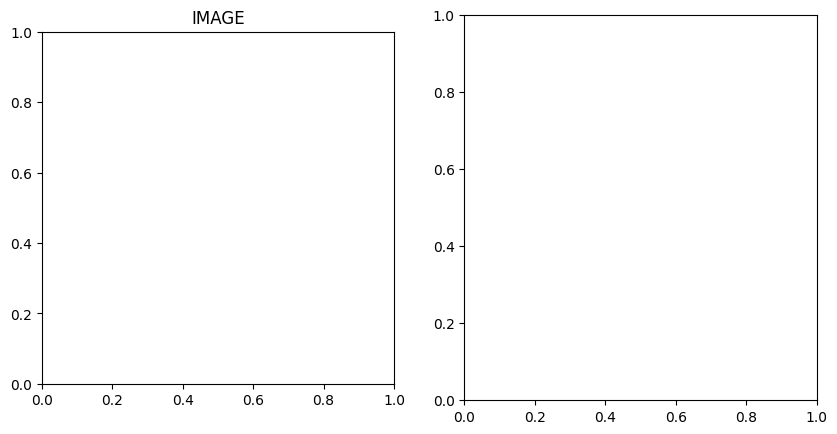

In [9]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

ax1.set_title('IMAGE')
ax1.imshow(image)

ax2.set_title('GROUND TRUTH')
ax2.imshow(mask,cmap = 'gray')

In [10]:
train_df,val_df = train_test_split(df,test_size = 0.2, random_state= 42)
len(train_df)


3143

In [11]:
print(train_df.size)

6286


# Task 3 : Augmentation Functions

albumentation documentation : https://albumentations.ai/docs/

In [12]:
import albumentations as A

In [13]:
def get_train_augs():
  return A.Compose([
      A.Resize(IMG_SIZE,IMG_SIZE),
      A.HorizontalFlip(p=.5),
      A.VerticalFlip(p= 0.5)
  ])
def get_valid_augs():
  return A.Compose([
      A.Resize(IMG_SIZE,IMG_SIZE)
  ])

# Task 4 : Create Custom Dataset

In [14]:
from torch.utils.data import Dataset


In [15]:
class SegmentationData(Dataset):
  def __init__(self,df,augmentations):
    self.df =df
    self.augmentations = augmentations
  def __len__(self):
    return len(self.df)

  def __getitem__(self,idx):
    row = df.iloc[idx]
    image_path = DATA_DIR +'/train/images/'+ row.images
    mask_path = DATA_DIR + '/train/masks/'+row.masks
    image = cv2.imread(image_path,cv2.IMREAD_COLOR) #(h,w,c)
    mask = cv2.imread(mask_path,cv2.IMREAD_GRAYSCALE) #(h,w)
    mask = np.expand_dims(mask,axis= -1) #(h,w,c)
    #print(mask.shape)

    if self.augmentations:
      data = self.augmentations(image = image, mask = mask) #return a dictionary
      image = data['image']
      mask = data['mask']
      #print(mask.shape)

    image = np.transpose(image,(2,0,1)).astype(np.float32) #(channel,h,w)
    mask =  np.transpose(mask,(2,0,1)).astype(np.float32) #(channel,h,w)
    image = torch.tensor(image)/255 #making the float to 0 to 1
    mask = torch.round(torch.tensor(mask)/255) #making the float to 0 to 1
    return image,mask

In [16]:
train_dataset = SegmentationData(train_df,get_train_augs())
valid_dataset = SegmentationData(val_df,get_valid_augs())

In [17]:
len(train_dataset)

3143

In [18]:
idx = 3
image,mask = train_dataset[idx]

[ WARN:0@74.830] global loadsave.cpp:268 findDecoder imread_('data/MRI_kaggle/kaggle_3m/train/images/TCGA_CS_4941_19960909_12.tif'): can't open/read file: check file path/integrity
[ WARN:0@74.831] global loadsave.cpp:268 findDecoder imread_('data/MRI_kaggle/kaggle_3m/train/masks/TCGA_CS_4941_19960909_13_mask.tif'): can't open/read file: check file path/integrity


AttributeError: 'NoneType' object has no attribute 'shape'

In [ ]:
mask.shape

In [ ]:
helper.show_image(image,mask)

# Task 5 : Load dataset into batches

In [ ]:
from torch.utils.data import DataLoader

In [ ]:
train_loader = DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True)
valid_loader = DataLoader(valid_dataset,batch_size= BATCH_SIZE)


In [ ]:
print(f'Total number of images in train set : {len(train_dataset)}')
print(f'Total number of images in validation set : {len(valid_dataset)}')

In [ ]:
print(f'Total number of batches in train loader : {len(train_loader)}')
print(f'Total number of batches in validation loader : {len(valid_loader)}')

In [ ]:
for images,mask in train_loader:
  print(images.shape)
  print(mask.shape)
  break

In [ ]:
for images,mask in valid_loader:
  print(images.shape)
  print(mask.shape)
  break

# Task 6 : Create Segmentation Model

segmentation_models_pytorch documentation : https://smp.readthedocs.io/en/latest/

In [ ]:

import segmentation_models_pytorch as smp
from segmentation_models_pytorch.losses import DiceLoss

from torch import nn


In [ ]:
class SegmentationModel(nn.Module):
  def __init__(self):
    super(SegmentationModel,self).__init__()
    self.backbone = smp.Unet(
        encoder_name = ENCODER,
        encoder_weights = WEIGHTS,
        in_channels = 3,
        classes = 1,
        activation = None
    )
  def forward(self,images,masks = None):
    logits = self.backbone(images)
    if masks is not  None:
      return logits, DiceLoss(mode = 'binary')(logits,masks)+nn.BCEWithLogitsLoss()(logits,masks)

    return logits

In [ ]:
model = SegmentationModel().to(DEVICE)

# Task 7 : Create Train and Validation Function

In [ ]:
from torch.amp import autocast, GradScaler

# Initialize GradScaler
scaler = GradScaler()

def train_fn(train_loader, model, optimizer):
    model.train()
    total_loss = 0
    for images, masks in tqdm(train_loader):
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)
        
        optimizer.zero_grad()

        # Using autocast to automatically use mixed precision during the forward pass
        with autocast(device_type="cuda", dtype=torch.float16):
            logits,loss= model(images, masks)
        
        # Scale the loss and backpropagate with GradScaler
        scaler.scale(loss).backward()

        # Unscale gradients and apply the optimizer
        scaler.step(optimizer)
        
        # Update the scale for next iteration
        scaler.update()
        
        total_loss += loss.item()

    return total_loss / len(train_loader)


In [ ]:


def eval_fn(data_loader, model):
    model.eval()  # to turn on the dropout, batchnorm, etc.
    total_loss = 0
    with torch.no_grad():
        for images, masks in tqdm(data_loader):
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)
            
            # Use autocast to reduce memory usage during the forward pass
            with autocast(device_type="cuda", dtype=torch.float16):
                logits,loss = model(images, masks)
               
            total_loss += loss.item()
    
    return total_loss / len(data_loader)





# Task 8 : Train Model

In [ ]:
optimizer = torch.optim.Adam(model.parameters(),lr=LR)

In [ ]:
best_loss = np.inf
train_losses = []
valid_losses = []
for i in range(EPOCH):
  train_loss = train_fn(train_loader,model,optimizer)
  valid_loss = eval_fn(valid_loader,model)
  train_losses.append(train_loss)
  valid_losses.append(valid_loss)
  if valid_loss < best_loss:
    best_loss = valid_loss
    # Save the model's state_dict for inference
  torch.save({
    'model_state_dict': model.state_dict(),
  }, 'model_for_aerial_segment.pth')


  print(f'Epoch : {i+1} Train Loss : {train_loss} Valid Loss : {valid_loss}')
# ✅ After training, plot the graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCH + 1), train_losses, label="Train Loss", marker='o')
plt.plot(range(1, EPOCH + 1), valid_losses, label="Valid Loss", marker='s')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Over Epochs")
plt.legend()
plt.grid(True)
plt.show()

# Task 9 : Inference

In [ ]:
idx = 7

checkpoint = torch.load('model_for_aerial_segment.pth')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
image,mask = valid_dataset[idx]
logits_mask = model(image.to(DEVICE).unsqueeze(0)) #logits are the raw output without sigmoid or activation function , so the model ouput is (c,h,w ) but fpr prediction it needs batch. that's wht the squeex, it will add a extra dimension for batch
pred_mask = torch.sigmoid(logits_mask)
pred_mask = (pred_mask > 0.5)*1.0  #making 0 and 1 for binary segmentation
pred_mask = pred_mask.detach().cpu().squeeze(0) # so for printing the predicted image we need to remove the batch.


In [ ]:
helper.show_image(image,mask,pred_mask)